In [100]:
# Install all packages required for this talktorial
%pip install requests pandas rdkit

Note: you may need to restart the kernel to use updated packages.


In [101]:
import math
from pathlib import Path

import requests

import pandas as pd

# PandasTool is not required


In [102]:


HERE = Path(_dh[-1])
DATA = HERE / "data"



In [103]:
BASE_URL = "https://www.ebi.ac.uk/chembl/api/data"

# Function to get JSON data from a the ChEMBL REST endpoint, handling pagination 
def get_json(endpoint, params=None):
    params = params.copy() if params else {}
    params.setdefault("limit", 1000)

    records = []
    offset = 0

    while True:
        params["offset"] = offset

        response = requests.get(
            f"{BASE_URL}/{endpoint}.json",
            params=params,
            headers={"Accept": "application/json"},
            timeout=30,
        )

        response.raise_for_status()
        data = response.json()
        collection_name = next(
            key
            for key in data.keys()
            if isinstance(data[key], list)
        )

        batch = data[collection_name]

        if not batch:
            break

        records.extend(batch)

        if len(batch) < params["limit"]:
            break

        offset += params["limit"]

    return records


In [104]:
# Search for targets in chembl from uniprot_id and return a pandas DataFrame with the results
def get_targets(uniprot_id):
    targets = get_json(
        "target",
        {
            "target_components__accession": uniprot_id
        }
    )

    targets = pd.DataFrame(targets)

    # Add columns to the DataFrame if it is not empty
    if not targets.empty:
        columns = [
            "target_chembl_id",
            "organism",
            "pref_name",
            "target_type",
        ]

        targets = targets[columns]

    return targets

In [105]:
# Search for activities in chembl using a target_chembl_id and return a pandas DataFrame with the results
def get_activities(
    target_chembl_id,
    activity_type="IC50",
    relation="=",
    assay_type="B",
):

    activities = get_json(
        "activity",
        {
            "target_chembl_id": target_chembl_id,
            "type": activity_type,
            "relation": relation,
            "assay_type": assay_type,
        },
    )

    activities = pd.DataFrame(activities)

    if not activities.empty:
        columns = [
            "activity_id",
            "assay_chembl_id",
            "assay_description",
            "assay_type",
            "molecule_chembl_id",
            "type",
            "standard_units",
            "relation",
            "standard_value",
            "target_chembl_id",
            "target_organism",
        ]

        available = [
            c for c in columns
            if c in activities.columns
        ]

        activities = activities[available]

    return activities


In [106]:
# Search for compounds in chembl using a list of molecule_chembl_ids and return a pandas DataFrame with the results
def get_compounds(molecule_chembl_ids, batch_size=100):

    molecule_chembl_ids = list(set(molecule_chembl_ids))
    compounds = []

    for start in range(0, len(molecule_chembl_ids), batch_size):
        batch = molecule_chembl_ids[start:start + batch_size]
        ids = ";".join(batch)

        data = get_json(
            f"molecule/set/{ids}"
        )
        for molecule in data:
            compounds.append(
                {
                    "molecule_chembl_id": molecule["molecule_chembl_id"],
                    "molecule_structures": molecule["molecule_structures"],
                }
            )

        print(
            f"Retrieved {len(compounds)} compounds...",
            end="\r"
        )

    return pd.DataFrame(compounds)

In [107]:
uniprot_id = "P14416"

In [108]:
# Get target information from ChEMBL but restrict it to specified values only
targets = get_targets(uniprot_id)

print(f"The type of targets is {type(targets)}")

The type of targets is <class 'pandas.DataFrame'>


In [109]:
# Let's have a look at the target information we retrieved from ChEMBL
targets.head()

,target_chembl_id,organism,pref_name,target_type
0,CHEMBL217,Homo sapiens,D(2) dopamine receptor,SINGLE PROTEIN
1,CHEMBL2095169,Homo sapiens,Dopamine receptors; D2 & D3,SELECTIVITY GROUP
2,CHEMBL2095396,Homo sapiens,Dopamine receptors; D2 & D4,SELECTIVITY GROUP
3,CHEMBL2096905,Homo sapiens,Dopamine receptor,PROTEIN FAMILY
4,CHEMBL2111460,Homo sapiens,Dopamine D2 receptor and serotonin 1a receptor,SELECTIVITY GROUP


In [110]:
target = targets.iloc[0]
target

target_chembl_id                 CHEMBL217
organism                      Homo sapiens
pref_name           D(2) dopamine receptor
target_type                 SINGLE PROTEIN
Name: 0, dtype: str

In [111]:
chembl_id = target.target_chembl_id
print(f"The target ChEMBL ID is {chembl_id}")

The target ChEMBL ID is CHEMBL217


In [112]:
bioactivities = get_activities(chembl_id)

print(
    f"Length and type of bioactivities object: "
    f"{len(bioactivities)}, {type(bioactivities)}"
)


Length and type of bioactivities object: 514, <class 'pandas.DataFrame'>


In [113]:
# Check the number of unique molecules
print(bioactivities["molecule_chembl_id"].nunique())

435


In [114]:
bioactivities.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,type,standard_units,relation,standard_value,target_chembl_id,target_organism
0,32111,CHEMBL671073,Binding affinity to cloned human Dopamine rece...,B,CHEMBL303519,IC50,nM,=,9800.0,CHEMBL217,Homo sapiens
1,33282,CHEMBL671073,Binding affinity to cloned human Dopamine rece...,B,CHEMBL292943,IC50,nM,=,50.0,CHEMBL217,Homo sapiens
2,38258,CHEMBL671073,Binding affinity to cloned human Dopamine rece...,B,CHEMBL61682,IC50,nM,=,25.0,CHEMBL217,Homo sapiens
3,39387,CHEMBL671073,Binding affinity to cloned human Dopamine rece...,B,CHEMBL64487,IC50,nM,=,360.0,CHEMBL217,Homo sapiens
4,39391,CHEMBL671073,Binding affinity to cloned human Dopamine rece...,B,CHEMBL64597,IC50,nM,=,300.0,CHEMBL217,Homo sapiens


In [115]:
bioactivities.dtypes

activity_id           int64
assay_chembl_id         str
assay_description       str
assay_type              str
molecule_chembl_id      str
type                    str
standard_units          str
relation                str
standard_value          str
target_chembl_id        str
target_organism         str
dtype: object

In [116]:
bioactivities = bioactivities.astype({"standard_value": "float64"})
bioactivities.dtypes

activity_id             int64
assay_chembl_id           str
assay_description         str
assay_type                str
molecule_chembl_id        str
type                      str
standard_units            str
relation                  str
standard_value        float64
target_chembl_id          str
target_organism           str
dtype: object

In [117]:
bioactivities.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {bioactivities.shape}")

DataFrame shape: (514, 11)


In [118]:
print(f"Units in downloaded data: {bioactivities['standard_units'].unique()}")
print(
    f"Number of non-nM entries:\
    {bioactivities[bioactivities['standard_units'] != 'nM'].shape[0]}"
)

Units in downloaded data: <StringArray>
['nM']
Length: 1, dtype: str
Number of non-nM entries:    0


In [119]:
bioactivities = bioactivities[bioactivities["standard_units"] == "nM"]
print(f"Units after filtering: {bioactivities['standard_units'].unique()}")

Units after filtering: <StringArray>
['nM']
Length: 1, dtype: str


In [120]:
print(f"DataFrame shape: {bioactivities.shape}")

DataFrame shape: (514, 11)


In [121]:
bioactivities.drop_duplicates("molecule_chembl_id", keep="first", inplace=True)
print(f"DataFrame shape: {bioactivities.shape}")

DataFrame shape: (435, 11)


In [122]:
bioactivities.reset_index(drop=True, inplace=True)
bioactivities.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,type,standard_units,relation,standard_value,target_chembl_id,target_organism
0,32111,CHEMBL671073,Binding affinity to cloned human Dopamine rece...,B,CHEMBL303519,IC50,nM,=,9800.0,CHEMBL217,Homo sapiens
1,33282,CHEMBL671073,Binding affinity to cloned human Dopamine rece...,B,CHEMBL292943,IC50,nM,=,50.0,CHEMBL217,Homo sapiens
2,38258,CHEMBL671073,Binding affinity to cloned human Dopamine rece...,B,CHEMBL61682,IC50,nM,=,25.0,CHEMBL217,Homo sapiens
3,39387,CHEMBL671073,Binding affinity to cloned human Dopamine rece...,B,CHEMBL64487,IC50,nM,=,360.0,CHEMBL217,Homo sapiens
4,39391,CHEMBL671073,Binding affinity to cloned human Dopamine rece...,B,CHEMBL64597,IC50,nM,=,300.0,CHEMBL217,Homo sapiens


In [123]:
bioactivities.rename(
    columns={"standard_value": "IC50", "standard_units": "units"}, inplace=True
)
bioactivities.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,type,units,relation,IC50,target_chembl_id,target_organism
0,32111,CHEMBL671073,Binding affinity to cloned human Dopamine rece...,B,CHEMBL303519,IC50,nM,=,9800.0,CHEMBL217,Homo sapiens
1,33282,CHEMBL671073,Binding affinity to cloned human Dopamine rece...,B,CHEMBL292943,IC50,nM,=,50.0,CHEMBL217,Homo sapiens
2,38258,CHEMBL671073,Binding affinity to cloned human Dopamine rece...,B,CHEMBL61682,IC50,nM,=,25.0,CHEMBL217,Homo sapiens
3,39387,CHEMBL671073,Binding affinity to cloned human Dopamine rece...,B,CHEMBL64487,IC50,nM,=,360.0,CHEMBL217,Homo sapiens
4,39391,CHEMBL671073,Binding affinity to cloned human Dopamine rece...,B,CHEMBL64597,IC50,nM,=,300.0,CHEMBL217,Homo sapiens


In [124]:
print(f"DataFrame shape: {bioactivities.shape}")

DataFrame shape: (435, 11)


In [125]:
print(len(bioactivities))
print(bioactivities["molecule_chembl_id"].nunique())

435
435


In [126]:
compounds = get_compounds(bioactivities["molecule_chembl_id"].unique())

In [127]:
compounds.head()

,molecule_chembl_id,molecule_structures
0,CHEMBL1202225,{'canonical_smiles': 'Br.Clc1cc(Cl)cc(N2CCN(C[...
1,CHEMBL2016626,{'canonical_smiles': 'O=C(CCCCC(=O)NCCCN1CCN(C...
2,CHEMBL1202209,{'canonical_smiles': 'Br.Cc1cc(F)ccc1N1CCN(C[C...
3,CHEMBL564,{'canonical_smiles': 'CN(C)CCCN1c2ccccc2Sc2ccc...
4,CHEMBL5885759,{'canonical_smiles': 'O=C1CCc2ccc(CCN3CCC(c4cc...


In [128]:
compounds.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {compounds.shape}")

DataFrame shape: (435, 2)


In [129]:
print(f"Bioactivities filtered: {bioactivities.shape[0]}")
bioactivities.columns

Bioactivities filtered: 435


Index(['activity_id', 'assay_chembl_id', 'assay_description', 'assay_type',
       'molecule_chembl_id', 'type', 'units', 'relation', 'IC50',
       'target_chembl_id', 'target_organism'],
      dtype='str')

In [130]:
print(f"Compounds filtered: {compounds.shape[0]}")
compounds.columns

Compounds filtered: 435


Index(['molecule_chembl_id', 'molecule_structures'], dtype='str')

In [131]:
# Merge DataFrames
output_df = pd.merge(
    bioactivities[["molecule_chembl_id", "IC50", "units"]],
    compounds,
    on="molecule_chembl_id",
)

# Reset row indices
output_df.reset_index(drop=True, inplace=True)

print(f"Dataset with {output_df.shape[0]} entries.")

Dataset with 435 entries.


In [132]:
output_df.dtypes

molecule_chembl_id         str
IC50                   float64
units                      str
molecule_structures     object
dtype: object

In [133]:
output_df.head(10)

,molecule_chembl_id,IC50,units,molecule_structures
0,CHEMBL303519,9800.0,nM,{'canonical_smiles': 'c1cnc(N2CCN(Cc3cccc4c3Cc...
1,CHEMBL292943,50.0,nM,{'canonical_smiles': 'COc1ccc(-c2cccc(CN3CCN(c...
2,CHEMBL61682,25.0,nM,{'canonical_smiles': 'Fc1ccc(-c2cncc(CN3CCN(c4...
3,CHEMBL64487,360.0,nM,{'canonical_smiles': 'COc1ccccc1-c1cccc(CN2CCN...
4,CHEMBL64597,300.0,nM,{'canonical_smiles': 'c1cnc(N2CCN(Cc3cccc(-c4c...
5,CHEMBL291824,70.0,nM,{'canonical_smiles': 'Fc1ccc(-c2cncc(CN3CCN(c4...
6,CHEMBL59942,49.0,nM,{'canonical_smiles': 'Fc1ccc(-c2cccc(CN3CCN(c4...
7,CHEMBL61657,60.0,nM,{'canonical_smiles': 'Fc1ccc(-c2cncc(CN3CCN(c4...
8,CHEMBL302183,120.0,nM,{'canonical_smiles': 'Fc1ccc(-c2cncc(CN3CCN(c4...
9,CHEMBL304692,2300.0,nM,{'canonical_smiles': 'c1cnc(N2CCN(Cc3cccc4c3-c...


In [134]:
def convert_ic50_to_pic50(IC50_value):
    pIC50_value = 9 - math.log10(IC50_value)
    return pIC50_value

In [135]:
# Apply conversion to each row of the compounds DataFrame
output_df["pIC50"] = output_df.apply(lambda x: convert_ic50_to_pic50(x.IC50), axis=1)

In [136]:
output_df.head()

,molecule_chembl_id,IC50,units,molecule_structures,pIC50
0,CHEMBL303519,9800.0,nM,{'canonical_smiles': 'c1cnc(N2CCN(Cc3cccc4c3Cc...,5.008774
1,CHEMBL292943,50.0,nM,{'canonical_smiles': 'COc1ccc(-c2cccc(CN3CCN(c...,7.301030
2,CHEMBL61682,25.0,nM,{'canonical_smiles': 'Fc1ccc(-c2cncc(CN3CCN(c4...,7.602060
3,CHEMBL64487,360.0,nM,{'canonical_smiles': 'COc1ccccc1-c1cccc(CN2CCN...,6.443697
4,CHEMBL64597,300.0,nM,{'canonical_smiles': 'c1cnc(N2CCN(Cc3cccc(-c4c...,6.522879


array([[<Axes: title={'center': 'pIC50'}>]], dtype=object)

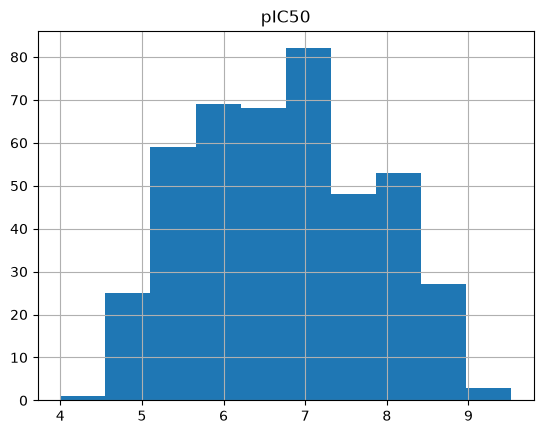

In [137]:
output_df.hist(column="pIC50")

In [138]:
from rdkit import Chem

#Deze heb ik veranderd met copilot, belangrijk om na te checken
#Add molecule column
# Extract SMILES from the ChEMBL structure dictionaries
output_df["smiles"] = output_df["molecule_structures"].apply(
    lambda structure: structure.get("canonical_smiles")
    if isinstance(structure, dict)
    else None
)

# Add RDKit molecule objects
output_df["ROMol"] = output_df["smiles"].apply(
    lambda smiles: Chem.MolFromSmiles(smiles) if pd.notna(smiles) else None
)

In [139]:
# Sort molecules by pIC50
output_df.sort_values(by="pIC50", ascending=False, inplace=True)

# Reset index
output_df.reset_index(drop=True, inplace=True)

In [140]:
output_df.drop("molecule_structures", axis=1).head(3)

,molecule_chembl_id,IC50,units,pIC50,smiles,ROMol
0,CHEMBL567,0.30,nM,9.522879,OCCN1CCN(CCCN2c3ccccc3Sc3ccc(Cl)cc32)CC1,<rdkit.Chem.rdchem.Mol object at 0x000001566DF...
1,CHEMBL6004129,0.98,nM,9.008774,COc1ccccc1N1CCN(CCCCOc2ccc3c(c2)NC(=O)CO3)CC1,<rdkit.Chem.rdchem.Mol object at 0x00000156745...
2,CHEMBL5851827,1.06,nM,8.974694,O=C1CCc2cc(CCCCN3CCN(c4cccc5sc(F)cc45)CC3)ccc2N1,<rdkit.Chem.rdchem.Mol object at 0x00000156745...


In [141]:
# Prepare saving the dataset: Drop the ROMol column
output_df = output_df.drop("ROMol", axis=1)
print(f"DataFrame shape: {output_df.shape}")

DataFrame shape: (435, 6)


In [142]:
chembl_df = output_df[
    ["molecule_chembl_id", "pIC50", "smiles"]
].copy()

chembl_df = chembl_df.rename(columns={"molecule_chembl_id": "CHEMBLid"})
chembl_df.head()

chembl_df.to_csv(DATA / "DopamineD2_compounds.csv", index=False)

In [143]:
print(f"DataFrame shape: {output_df.shape}")
# NBVAL_CHECK_OUTPUT

DataFrame shape: (435, 6)


In [144]:
# Save the ChEMBL ID, pIC50, and SMILES together.
DATA.mkdir(parents=True, exist_ok=True)
output_df = output_df[["molecule_chembl_id", "pIC50", "smiles"]].copy()
output_df = output_df.rename(columns={"molecule_chembl_id": "CHEMBLid"})
output_df.to_csv(DATA / "DopamineD2_compounds.csv", index=False)


output_df.head(5)


,CHEMBLid,pIC50,smiles
0,CHEMBL567,9.522879,OCCN1CCN(CCCN2c3ccccc3Sc3ccc(Cl)cc32)CC1
1,CHEMBL6004129,9.008774,COc1ccccc1N1CCN(CCCCOc2ccc3c(c2)NC(=O)CO3)CC1
2,CHEMBL5851827,8.974694,O=C1CCc2cc(CCCCN3CCN(c4cccc5sc(F)cc45)CC3)ccc2N1
3,CHEMBL8514,8.958607,CC(C)(C)[C@]1(O)CCN2C[C@H]3c4ccccc4CCc4cccc(c4...
4,CHEMBL3885419,8.958607,CC(C)(C)[C@]1(O)CCN2C[C@@H]3c4ccccc4CCc4cccc(c...


In [145]:
print(f"DataFrame shape: {output_df.shape}")
# NBVAL_CHECK_OUTPUT

DataFrame shape: (435, 3)
